# Forward Modelling - 8x8 complex walk montage

Does forward modelling using the **Colin27 template**

1. Load one SNIRF file
2. Register optodes to Colin27 scalp (landmarks added from digpts.txt)
3. Compute forward model sensitivity matrix via nirfaster (i.e. channel space -> surface space matrix)

For details on each step, see Cedalion docs:
- [Tutorial 1 – Heads and Forward Models](https://doc.ibs.tu-berlin.de/cedalion/doc/dev/examples/tutorial/1_heads_and_fwm.html)
- [Tutorial 5 – Image Reconstruction](https://doc.ibs.tu-berlin.de/cedalion/doc/dev/examples/tutorial/5_image_reconstruction.html)


In [1]:
import glob
import os

import cedalion
import cedalion.dataclasses
import cedalion.dot
import cedalion.io
import cedalion.io.snirf
import cedalion.nirs
import cedalion.nirs.cw
import cedalion.sigproc.motion as motion
import cedalion.sigproc.physio as physio
import cedalion.sigproc.quality as quality
import cedalion.vis.anatomy
import cedalion.vis.blocks as vbx
from cedalion import units

import pyvista as pv
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr

np.set_printoptions(suppress=True)

# BIDS paths
task      = "complexwalk"
session   = "protocol1"
bids_root = "../../Park-MOVE_fnirs_dataset_v2/fNIRS_data/bids_dataset_snirf"
fwm_dir   = "../data/forward_model"
os.makedirs(fwm_dir, exist_ok=True)

# What counts as a short channel?
DIST_THRESHOLD = 1.5 * units.cm 

# Get all SNIRF files
snirf_files = sorted(glob.glob(
    f"{bids_root}/sub-*/ses-{session}/nirs/sub-*_task-{task}_nirs.snirf"
))
print(f"Found {len(snirf_files)} subjects")

Found 130 subjects


## Load example data

Load data and plot montage.

Amplitude shape: {'channel': 33, 'wavelength': 2, 'time': 7604}
Wavelengths (nm): [760. 850.]


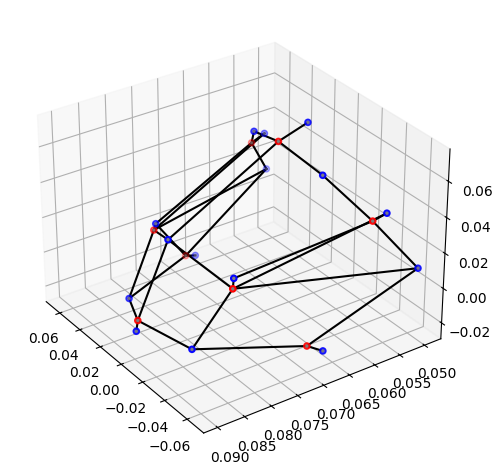

In [2]:
fname = snirf_files[0]
rec = cedalion.io.snirf.read_snirf(fname)[0]

amp = rec.get_timeseries()
print("Amplitude shape:", dict(amp.sizes))
print("Wavelengths (nm):", amp.wavelength.values)

# Plot montage
cedalion.vis.anatomy.montage.plot_montage3D(rec['amp'], rec.geo3d)

Geo3d labels: ['S1' 'S2' 'S3' 'S4' 'S5' 'S6' 'S7' 'S8' 'D1' 'D2' 'D3' 'D4' 'D5' 'D6'
 'D7' 'D8' 'D9' 'D10' 'D11' 'D12' 'D13' 'D14' 'D15' 'HP_1' 'HP_2' 'HP_3'
 'HP_4' 'HP_5' 'HP_6' 'HP_7' 'HP_8' 'HP_9' 'HP_10' 'HP_11' 'HP_12' 'HP_13'
 'HP_14' 'HP_15' 'HP_16' 'HP_17' 'HP_18' 'HP_19' 'HP_20' 'HP_21' 'HP_22'
 'HP_23' 'Nz' 'Cz' 'Iz' 'LPA' 'RPA']


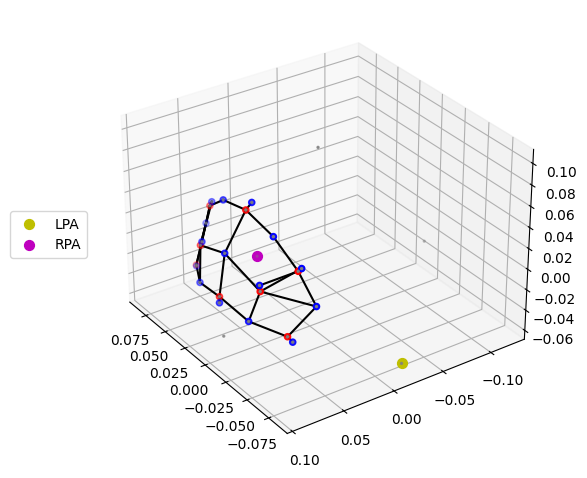

In [3]:
# Add cranial landmarks (missing from SNIRF files; taken from digpts.txt)
lm_labels = np.array(["Nz", "Cz", "Iz", "LPA", "RPA"])
lm_pos_mm = np.array([
    [ 0.400,  85.900, -47.600],
    [-0.461,  -8.416, 101.365],
    [ 0.200, -120.500, -25.800],
    [-83.800, -18.600, -57.200],
    [ 83.900, -16.600, -56.700],
])
lm_types  = [cedalion.dataclasses.PointType.LANDMARK] * len(lm_labels)
lm_coords = {"label": ("label", lm_labels), "type": ("label", lm_types)}
lm_arr = (
    xr.DataArray(lm_pos_mm / 1000, dims=["label", "pos"],
                 coords=lm_coords, attrs={"units": "m"})
    .set_xindex("type")
    .pint.quantify()
)

# Add to montage object
geo3d = xr.concat([rec.geo3d, lm_arr], dim="label")
print("Geo3d labels:", geo3d.label.values)

# Plot montage
cedalion.vis.anatomy.montage.plot_montage3D(rec['amp'], geo3d, landmarks=["LPA", "RPA", "NASION"])

## Get template head model

In [4]:
head_ijk = cedalion.dot.get_standard_headmodel("colin27")

print("Scalp vertices:", head_ijk.scalp)
print("Brain vertices:", head_ijk.brain)
print("Landmarks:", head_ijk.landmarks.label.values)

Scalp vertices: TrimeshSurface(faces: 20096 vertices: 10050 crs: ijk units: dimensionless vertex_coords: [])
Brain vertices: TrimeshSurface(faces: 49992 vertices: 25000 crs: ijk units: dimensionless vertex_coords: ['fsaverage_vertex', 'parcel', 'mni152_r', 'mni152_a', 'mni152_s'])
Landmarks: ['Iz' 'LPA' 'RPA' 'Nz' 'Cz' 'T7' 'T8' 'Fpz' 'AFz' 'Fz' 'FCz' 'CPz' 'Pz'
 'POz' 'Oz' 'Fp1' 'AF7' 'F7' 'FT7' 'TP7' 'P7' 'PO7' 'O1' 'Fp2' 'AF8' 'F8'
 'FT8' 'TP8' 'P8' 'PO8' 'O2' 'C5' 'C3' 'C1' 'C2' 'C4' 'C6' 'FC5' 'FC3'
 'FC1' 'FC2' 'FC4' 'FC6' 'F5' 'F3' 'F1' 'F2' 'F4' 'F6' 'AF5' 'AF3' 'AF1'
 'AF2' 'AF4' 'AF6' 'CP5' 'CP3' 'CP1' 'CP2' 'CP4' 'CP6' 'P5' 'P3' 'P1' 'P2'
 'P4' 'P6' 'PO5' 'PO3' 'PO1' 'PO2' 'PO4' 'PO6']


In [5]:
# Register optodes: snap to Colin27 scalp using the cranial landmarks
geo3d_snapped_ijk, alignment_details = head_ijk.align_and_relax_to_scalp(
    geo3d, amp
)
print("Snapped geo3d dims:", dict(geo3d_snapped_ijk.sizes))

head_ras = head_ijk.apply_transform(head_ijk.t_ijk2ras)
display(head_ras)

# Let's plot the montage on the head
plt = pv.Plotter()
vbx.plot_surface(plt, head_ijk.scalp, color="#4fce64", opacity=.1)
vbx.plot_labeled_points(plt, geo3d_snapped_ijk)
vbx.plot_labeled_points(
    plt, head_ijk.landmarks.sel(label=["Nz", "Iz", "Cz", "LPA", "RPA"]), color="y"
)
plt.show()

Snapped geo3d dims: {'label': 51, 'ijk': 3}


TwoSurfaceHeadModel(
  crs: mni
  tissue_types: csf, gm, scalp, skull, wm
  brain faces: 49992 vertices: 25000 units: millimeter
  scalp faces: 20096 vertices: 10050 units: millimeter
  landmarks: 73
)

<frozen abc>:123: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
2026-08-07 13:59:57.778 Python[57020:10053518] ApplePersistenceIgnoreState: Existing state will not be touched. New state will be written to /var/folders/m4/lwl45ymj7ygb_w4t_xhm9d6c0000gp/T/org.python.python.savedState


Widget(value='<iframe src="http://localhost:54344/index.html?ui=P_0x13269d810_0&reconnect=auto" class="pyvista…

## Compute forward model via photon transport simulation

The sensitivity matrix **Adot** (dims: `channel × vertex × wavelength`) is computed with the [micro (fast and furious) version of NIRFASTer](https://github.com/milabuob/nirfaster-uFF).

In [6]:
fluence_file     = f"{fwm_dir}/ParkMOVE_colin27_fluence.h5"
sensitivity_file = f"{fwm_dir}/ParkMOVE_colin27_Adot.h5"

if not os.path.exists(sensitivity_file):
    print("Computing forward model...")
    meas_list = rec._measurement_lists["amp"]
    fwm = cedalion.dot.ForwardModel(head_ijk, geo3d_snapped_ijk, meas_list)

    if not os.path.exists(fluence_file):
        fwm.compute_fluence_nirfaster(fluence_file)

    fwm.compute_sensitivity(fluence_file, sensitivity_file)
    print(f"Saved to {sensitivity_file}")
else:
    print(f"Loading cached sensitivity: {sensitivity_file}")

Adot = cedalion.io.load_Adot(sensitivity_file)
print("Adot dims:", dict(Adot.sizes))

Loading cached sensitivity: ../data/forward_model/ParkMOVE_colin27_Adot.h5
Adot dims: {'channel': 33, 'vertex': 35050, 'wavelength': 2}


## Visualize sensitivity matrix

The simulation also modelled the short channels so we identify those and only select the long channels.

In [7]:
import re 

# Existing split
amp_long, amp_short = cedalion.nirs.split_long_short_channels(
    amp, rec.geo3d, DIST_THRESHOLD
)

# Additional MATLAB-style short channels
detector_ids = np.array([
    int(re.search(r"D(\d+)$", ch).group(1))
    for ch in amp.channel.values
])

extra_short = amp.channel.values[detector_ids >= 8]

# Union of both definitions
all_short = np.union1d(
    amp_short.channel.values,
    extra_short
)

all_long = np.setdiff1d(
    amp.channel.values,
    all_short
)

amp_short = amp.sel(channel=all_short)
amp_long = amp.sel(channel=all_long)

print(f"Long channels: {amp_long.sizes['channel']}")
print(f"Short channels: {amp_short.sizes['channel']}")

# Restrict Adot to long channels
shared_channels = np.intersect1d(Adot.channel.values, amp_long.channel.values)
Adot_long = Adot.sel(channel=shared_channels)
print(f"Long channels in Adot: {len(shared_channels)}")

Long channels: 20
Short channels: 13
Long channels in Adot: 20


In [8]:
# Select only a subset of labeled points to plot
# Here we select sources and detectors via their labels that start with S or D
# I.e. skip landmarks and channel centers
geo3d_plot_ijk = geo3d_snapped_ijk.sel(
    label=geo3d_snapped_ijk.label.str.contains("S|D")
)

plotter = cedalion.vis.anatomy.sensitivity_matrix.Main(
    sensitivity=Adot_long,
    brain_surface=head_ijk.brain,
    head_surface=head_ijk.scalp,
    labeled_points= geo3d_plot_ijk,
)
plotter.plot(high_th=0, low_th=-2)
plotter.plt.show()

/Users/alexander.kvist/project_local/fNIRS_navigation_study/venv_notebook/lib/python3.11/site-packages/trame_vtk/modules/vtk/serializers/helpers.py:23: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  data[idx * nb_components : (idx + 1) * nb_components]


Widget(value='<iframe src="http://localhost:54344/index.html?ui=P_0x13267a110_1&reconnect=auto" class="pyvista…